In [147]:
# day 5 - feature engineering starts here
# i'm loading the cleaned tables from the last few days so i can build features without redoing all the cleanup

import pandas as pd
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

# this table has the order-level data joined with customer info
orders = pd.read_parquet(PROCESSED_DIR / "orders_with_customer.parquet")

# this table has my new delivery-delay label
labels = pd.read_parquet(PROCESSED_DIR / "delay_labels.parquet")

print(f"orders loaded: {len(orders):,}")
print(f"labels loaded: {len(labels):,}")
print()

# merging label + order data so i have one base table to build features from
# order_id is the safe key here because it uniquely identifies each order
base = orders.merge(
    labels[["order_id", "delay_days", "is_late"]],
    on="order_id",
    how="inner"
)

print(f"base table rows after merge: {len(base):,}")
print(f"base table columns: {base.shape[1]}")
print()
print("label balance in the base table:")
print(base["is_late"].value_counts())

orders loaded: 96,478
labels loaded: 96,470

base table rows after merge: 96,470
base table columns: 14

label balance in the base table:
is_late
0    89936
1     6534
Name: count, dtype: int64


In [148]:
# first feature group: time-based features
# extracting useful information from the purchase timestamp

# making sure purchase timestamp is datetime
base["order_purchase_timestamp"] = pd.to_datetime(
    base["order_purchase_timestamp"]
)

# basic calendar features
base["purchase_year"] = base["order_purchase_timestamp"].dt.year
base["purchase_month"] = base["order_purchase_timestamp"].dt.month
base["purchase_day"] = base["order_purchase_timestamp"].dt.day

# monday=0, sunday=6
base["purchase_weekday"] = base["order_purchase_timestamp"].dt.weekday

# hour of the day (0-23)
base["purchase_hour"] = base["order_purchase_timestamp"].dt.hour

# simple binary features
base["is_weekend"] = (
    base["purchase_weekday"] >= 5
).astype(int)

# month-end shopping sometimes behaves differently
base["is_month_end"] = (
    base["purchase_day"] >= 25
).astype(int)

print("new time features added:")
print([
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_weekday",
    "purchase_hour",
    "is_weekend",
    "is_month_end"
])

print()
print(base[[
    "order_purchase_timestamp",
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "is_weekend"
]].head())

new time features added:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_weekday', 'purchase_hour', 'is_weekend', 'is_month_end']

  order_purchase_timestamp  purchase_month  purchase_weekday  purchase_hour  \
0      2017-10-02 10:56:33              10                 0             10   
1      2018-07-24 20:41:37               7                 1             20   
2      2018-08-08 08:38:49               8                 2              8   
3      2017-11-18 19:28:06              11                 5             19   
4      2018-02-13 21:18:39               2                 1             21   

   is_weekend  
0           0  
1           0  
2           0  
3           1  
4           0  


In [149]:
# first feature group: time-based features
# extracting useful information from the purchase timestamp

# making sure purchase timestamp is datetime
base["order_purchase_timestamp"] = pd.to_datetime(
    base["order_purchase_timestamp"]
)

# basic calendar features
base["purchase_year"] = base["order_purchase_timestamp"].dt.year
base["purchase_month"] = base["order_purchase_timestamp"].dt.month
base["purchase_day"] = base["order_purchase_timestamp"].dt.day

# monday=0, sunday=6
base["purchase_weekday"] = base["order_purchase_timestamp"].dt.weekday

# hour of the day (0-23)
base["purchase_hour"] = base["order_purchase_timestamp"].dt.hour

# simple binary features
base["is_weekend"] = (
    base["purchase_weekday"] >= 5
).astype(int)

# month-end shopping sometimes behaves differently
base["is_month_end"] = (
    base["purchase_day"] >= 25
).astype(int)

print("new time features added:")
print([
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_weekday",
    "purchase_hour",
    "is_weekend",
    "is_month_end"
])

print()
print(base[[
    "order_purchase_timestamp",
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "is_weekend"
]].head())

new time features added:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_weekday', 'purchase_hour', 'is_weekend', 'is_month_end']

  order_purchase_timestamp  purchase_month  purchase_weekday  purchase_hour  \
0      2017-10-02 10:56:33              10                 0             10   
1      2018-07-24 20:41:37               7                 1             20   
2      2018-08-08 08:38:49               8                 2              8   
3      2017-11-18 19:28:06              11                 5             19   
4      2018-02-13 21:18:39               2                 1             21   

   is_weekend  
0           0  
1           0  
2           0  
3           1  
4           0  


In [150]:
# quick sanity checks:
# do these new features actually relate to late deliveries?

print("late-delivery rate by weekend vs weekday:")
print(
    base.groupby("is_weekend")["is_late"]
    .mean()
    .round(4) * 100
)
print()

print("late-delivery rate by purchase month:")
monthly_late_rate = (
    base.groupby("purchase_month")["is_late"]
    .mean()
    .round(4) * 100
)

print(monthly_late_rate.sort_values(ascending=False))

late-delivery rate by weekend vs weekday:
is_weekend
0    6.88
1    6.40
Name: is_late, dtype: float64

late-delivery rate by purchase month:
purchase_month
3     15.12
11    12.40
2     11.88
12     7.45
1      5.44
5      5.33
4      5.02
8      4.88
9      4.41
10     3.98
7      3.15
6      1.80
Name: is_late, dtype: float64


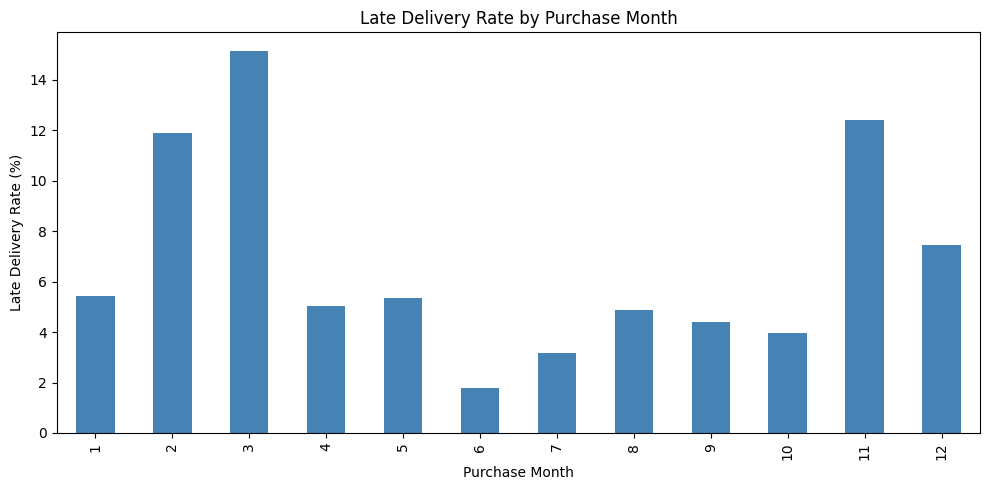

In [151]:
# plotting late-delivery rate by month
# visuals are easier to understand than raw numbers

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

monthly_late_rate.sort_index().plot(
    kind="bar",
    ax=ax,
    color="steelblue"
)

ax.set_title("Late Delivery Rate by Purchase Month")
ax.set_xlabel("Purchase Month")
ax.set_ylabel("Late Delivery Rate (%)")

plt.tight_layout()
plt.show()

In [152]:
# delivery promise features
# idea:
# some orders are given very aggressive delivery promises
# shorter promised windows are probably harder to meet

# how many days between purchase and promised delivery?
base["promised_delivery_days"] = (
    base["order_estimated_delivery_date"] -
    base["order_purchase_timestamp"]
).dt.days

print("delivery promise stats:")
print(base["promised_delivery_days"].describe())
print()

# checking whether shorter promises lead to more delays
promise_delay_rate = (
    base.groupby("promised_delivery_days")["is_late"]
    .mean()
    * 100
)

print("top delivery windows by late rate:")
print(
    promise_delay_rate
    .sort_values(ascending=False)
    .head(10)
)

delivery promise stats:
count    96470.000000
mean        23.372748
std          8.758421
min          2.000000
25%         18.000000
50%         23.000000
75%         28.000000
max        155.000000
Name: promised_delivery_days, dtype: float64

top delivery windows by late rate:
promised_delivery_days
69    33.333333
2     25.654450
3     15.602837
4     15.596330
5     15.254237
6     15.032680
7     10.073710
20     9.974149
22     8.333333
19     8.147513
Name: is_late, dtype: float64


In [153]:
# loading product-related tables
# these contain weight, dimensions, freight cost, seller id, etc.

order_items = pd.read_csv("../data/raw data/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw data/olist_products_dataset.csv")

print(f"order_items rows: {len(order_items):,}")
print(f"products rows:    {len(products):,}")
print()

# joining order_items with products
# this gives each order item its product dimensions and weight

items_with_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print(f"rows after join: {len(items_with_products):,}")
print()

print("columns now available:")
print(items_with_products.columns.tolist())

order_items rows: 112,650
products rows:    32,951

rows after join: 112,650

columns now available:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [154]:
# building product-level shipping features
# heavier and bigger products usually take more effort to ship
# freight cost ratio might also matter because it tells me how expensive shipping is compared to the item price

items_with_products["package_volume_cm3"] = (
    items_with_products["product_length_cm"] *
    items_with_products["product_height_cm"] *
    items_with_products["product_width_cm"]
)

items_with_products["freight_to_price_ratio"] = (
    items_with_products["freight_value"] / items_with_products["price"]
)

# quick cleanup for weird infinite / missing values
items_with_products["freight_to_price_ratio"] = (
    items_with_products["freight_to_price_ratio"]
    .replace([float("inf"), float("-inf")], pd.NA)
)

print("new product features added:")
print([
    "package_volume_cm3",
    "freight_to_price_ratio"
])

print()
print(items_with_products[[
    "product_weight_g",
    "package_volume_cm3",
    "price",
    "freight_value",
    "freight_to_price_ratio"
]].head())

new product features added:
['package_volume_cm3', 'freight_to_price_ratio']

   product_weight_g  package_volume_cm3   price  freight_value  \
0             650.0              3528.0   58.90          13.29   
1           30000.0             60000.0  239.90          19.93   
2            3050.0             14157.0  199.00          17.87   
3             200.0              2400.0   12.99          12.79   
4            3750.0             42000.0  199.90          18.14   

   freight_to_price_ratio  
0                0.225637  
1                0.083076  
2                0.089799  
3                0.984604  
4                0.090745  


In [155]:
# now building seller-level features
# idea:
# some sellers are consistently late, others are very reliable

# first i need seller_id attached to my base table
# pulling it from order_items

seller_lookup = order_items[[
    "order_id",
    "seller_id"
]].drop_duplicates()

base = base.merge(
    seller_lookup,
    on="order_id",
    how="left"
)

print(f"rows after seller merge: {len(base):,}")
print(f"unique sellers: {base['seller_id'].nunique():,}")
print()

# compute historical late rate per seller
seller_late_rate = (
    base.groupby("seller_id")["is_late"]
    .mean()
)

# attach it back to each row
base["seller_late_rate"] = (
    base["seller_id"]
    .map(seller_late_rate)
)

print("seller late-rate stats:")
print(base["seller_late_rate"].describe())
print()

print("sample seller late rates:")
print(base[[
    "seller_id",
    "seller_late_rate"
]].drop_duplicates().head())

rows after seller merge: 97,811
unique sellers: 2,970

seller late-rate stats:
count    97811.000000
mean         0.066935
std          0.056220
min          0.000000
25%          0.037037
50%          0.057654
75%          0.088635
max          1.000000
Name: seller_late_rate, dtype: float64

sample seller late rates:
                          seller_id  seller_late_rate
0  3504c0cb71d7fa48d967e0e4c94d59d9          0.000000
1  289cdb325fb7e7f891c38608bf9e0962          0.018349
2  4869f7a5dfa277a7dca6462dcf3b52b2          0.104982
3  66922902710d126a0e7d26b0e3805106          0.073333
4  2c9e548be18521d1c43cde1c582c6de8          0.153226


In [156]:
# product data is currently item-level
# but my prediction target is order-level
# so i need to aggregate item info into one row per order

order_product_features = (
    items_with_products
    .groupby("order_id")
    .agg({
        "price": "sum",
        "freight_value": "sum",
        "product_weight_g": "mean",
        "package_volume_cm3": "sum",
        "freight_to_price_ratio": "mean",
        "product_id": "count"
    })
    .rename(columns={
        "price": "total_order_value",
        "freight_value": "total_freight_value",
        "product_weight_g": "avg_product_weight_g",
        "package_volume_cm3": "total_package_volume_cm3",
        "freight_to_price_ratio": "avg_freight_price_ratio",
        "product_id": "n_items"
    })
    .reset_index()
)

print(f"rows in aggregated order feature table: {len(order_product_features):,}")
print()

print("new order-level product features:")
print(order_product_features.columns.tolist())
print()

print(order_product_features.head())

rows in aggregated order feature table: 98,666

new order-level product features:
['order_id', 'total_order_value', 'total_freight_value', 'avg_product_weight_g', 'total_package_volume_cm3', 'avg_freight_price_ratio', 'n_items']

                           order_id  total_order_value  total_freight_value  \
0  00010242fe8c5a6d1ba2dd792cb16214              58.90                13.29   
1  00018f77f2f0320c557190d7a144bdd3             239.90                19.93   
2  000229ec398224ef6ca0657da4fc703e             199.00                17.87   
3  00024acbcdf0a6daa1e931b038114c75              12.99                12.79   
4  00042b26cf59d7ce69dfabb4e55b4fd9             199.90                18.14   

   avg_product_weight_g  total_package_volume_cm3  avg_freight_price_ratio  \
0                 650.0                    3528.0                 0.225637   
1               30000.0                   60000.0                 0.083076   
2                3050.0                   14157.0            

In [157]:
# merging order-level product features into the main modeling table

base = base.merge(
    order_product_features,
    on="order_id",
    how="left"
)

print(f"final modeling table rows: {len(base):,}")
print(f"final modeling table columns: {base.shape[1]}")
print()

# checking for missingness in the new features
print("missing values in new product features:")
print(base[[
    "total_order_value",
    "total_freight_value",
    "avg_product_weight_g",
    "total_package_volume_cm3",
    "avg_freight_price_ratio",
    "n_items"
]].isnull().sum())

print()

print("sample rows from final feature table:")
print(base[[
    "is_late",
    "purchase_month",
    "promised_delivery_days",
    "seller_late_rate",
    "total_order_value",
    "avg_product_weight_g",
    "n_items"
]].head())

final modeling table rows: 97,811
final modeling table columns: 30

missing values in new product features:
total_order_value            0
total_freight_value          0
avg_product_weight_g        16
total_package_volume_cm3     0
avg_freight_price_ratio      0
n_items                      0
dtype: int64

sample rows from final feature table:
   is_late  purchase_month  promised_delivery_days  seller_late_rate  \
0        0              10                      15          0.000000   
1        0               7                      19          0.018349   
2        0               8                      26          0.104982   
3        0              11                      26          0.073333   
4        0               2                      12          0.153226   

   total_order_value  avg_product_weight_g  n_items  
0              29.99                 500.0        1  
1             118.70                 400.0        1  
2             159.90                 420.0        1  
3    

In [159]:
# saving the final modeling dataset

base.to_parquet(
    "../data/processed/modeling_dataset.parquet",
    index=False
)

print("modeling dataset saved successfully")
print("shape:", base.shape)

modeling dataset saved successfully
shape: (97811, 30)


In [ ]:
# building the final modeling dataframe
# removing leakage columns + ids i don't want the model to use

feature_cols = [
    # time features
    "purchase_month",
    "purchase_weekday",
    "purchase_hour",
    "is_weekend",
    "is_month_end",

    # delivery promise
    "promised_delivery_days",

    # seller
    "seller_late_rate",

    # product/logistics
    "total_order_value",
    "total_freight_value",
    "avg_product_weight_g",
    "total_package_volume_cm3",
    "avg_freight_price_ratio",
    "n_items",
]

target_col = "is_late"

# final ML table
ml_df = base[feature_cols + [target_col]].copy()

print(f"modeling dataframe shape: {ml_df.shape}")
print()

print("feature columns:")
for col in feature_cols:
    print(f" - {col}")

print()
print("target column:")
print(target_col)

print()
print("missing values:")
print(ml_df.isnull().sum())

modeling dataframe shape: (97811, 14)

feature columns:
 - purchase_month
 - purchase_weekday
 - purchase_hour
 - is_weekend
 - is_month_end
 - promised_delivery_days
 - seller_late_rate
 - total_order_value
 - total_freight_value
 - avg_product_weight_g
 - total_package_volume_cm3
 - avg_freight_price_ratio
 - n_items

target column:
is_late

missing values:
purchase_month               0
purchase_weekday             0
purchase_hour                0
is_weekend                   0
is_month_end                 0
promised_delivery_days       0
seller_late_rate             0
total_order_value            0
total_freight_value          0
avg_product_weight_g        16
total_package_volume_cm3     0
avg_freight_price_ratio      0
n_items                      0
is_late                      0
dtype: int64


In [ ]:
# only 16 rows are missing avg_product_weight_g
# filling with median instead of mean because product weights have extreme outliers

median_weight = ml_df["avg_product_weight_g"].median()

ml_df["avg_product_weight_g"] = (
    ml_df["avg_product_weight_g"]
    .fillna(median_weight)
)

print(f"median weight used for fill: {median_weight}")
print()

print("missing values after fill:")
print(ml_df.isnull().sum())

median weight used for fill: 700.0

missing values after fill:
purchase_month              0
purchase_weekday            0
purchase_hour               0
is_weekend                  0
is_month_end                0
promised_delivery_days      0
seller_late_rate            0
total_order_value           0
total_freight_value         0
avg_product_weight_g        0
total_package_volume_cm3    0
avg_freight_price_ratio     0
n_items                     0
is_late                     0
dtype: int64


In [ ]:
# train/test split using TIME instead of random shuffling
# this is much more realistic for business problems

# train = older orders
# test  = newer orders

split_date = pd.Timestamp("2018-06-01")

train_df = base[
    base["order_purchase_timestamp"] < split_date
]

test_df = base[
    base["order_purchase_timestamp"] >= split_date
]

print(f"train rows: {len(train_df):,}")
print(f"test rows:  {len(test_df):,}")
print()

print("train date range:")
print(train_df["order_purchase_timestamp"].min())
print("->")
print(train_df["order_purchase_timestamp"].max())
print()

print("test date range:")
print(test_df["order_purchase_timestamp"].min())
print("->")
print(test_df["order_purchase_timestamp"].max())
print()

print("late-delivery rate:")
print(f"train: {train_df['is_late'].mean() * 100:.2f}%")
print(f"test:  {test_df['is_late'].mean() * 100:.2f}%")

train rows: 78,874
test rows:  18,937

train date range:
2016-09-15 12:16:38
->
2018-05-31 23:51:24

test date range:
2018-06-01 00:39:55
->
2018-08-29 15:00:37

late-delivery rate:
train: 7.45%
test:  3.55%


In [ ]:
# creating the final ML inputs

# X = features
# y = target label

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("training feature matrix shape:")
print(X_train.shape)
print()

print("test feature matrix shape:")
print(X_test.shape)
print()

print("training labels:")
print(y_train.value_counts())
print()

print("test labels:")
print(y_test.value_counts())

training feature matrix shape:
(78874, 13)

test feature matrix shape:
(18937, 13)

training labels:
is_late
0    72999
1     5875
Name: count, dtype: int64

test labels:
is_late
0    18265
1      672
Name: count, dtype: int64


In [ ]:
# fixing the one feature that still has missing values
# i want to use the training data only to choose the fill value, so i don't peek at the test set

median_weight = train_df["avg_product_weight_g"].median()

train_df["avg_product_weight_g"] = train_df["avg_product_weight_g"].fillna(median_weight)
test_df["avg_product_weight_g"] = test_df["avg_product_weight_g"].fillna(median_weight)

# rebuilding X and y after the fill
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("missing values in train features:")
print(X_train.isnull().sum())
print()
print("missing values in test features:")
print(X_test.isnull().sum())

missing values in train features:
purchase_month              0
purchase_weekday            0
purchase_hour               0
is_weekend                  0
is_month_end                0
promised_delivery_days      0
seller_late_rate            0
total_order_value           0
total_freight_value         0
avg_product_weight_g        0
total_package_volume_cm3    0
avg_freight_price_ratio     0
n_items                     0
dtype: int64

missing values in test features:
purchase_month              0
purchase_weekday            0
purchase_hour               0
is_weekend                  0
is_month_end                0
promised_delivery_days      0
seller_late_rate            0
total_order_value           0
total_freight_value         0
avg_product_weight_g        0
total_package_volume_cm3    0
avg_freight_price_ratio     0
n_items                     0
dtype: int64


C:\Users\kruth\AppData\Local\Temp\ipykernel_29664\3965966499.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["avg_product_weight_g"] = train_df["avg_product_weight_g"].fillna(median_weight)
C:\Users\kruth\AppData\Local\Temp\ipykernel_29664\3965966499.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["avg_product_weight_g"] = test_df["avg_product_weight_g"].fillna(median_weight)


In [ ]:
# i want to make the train/test tables fully clean before modeling
# this should fix the NaN issue and avoid the copy warning too

import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# fresh copies so i don't keep any view/copy weirdness
train_df = train_df.copy()
test_df = test_df.copy()

# if any feature has inf or -inf, turn it into missing first
train_df = train_df.replace([np.inf, -np.inf], np.nan)
test_df = test_df.replace([np.inf, -np.inf], np.nan)

# rebuild X and y from the cleaned tables
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("train missing:")
print(X_train.isna().sum())
print()
print("test missing:")
print(X_test.isna().sum())
print()

# logistic regression baseline
# imputer fills any remaining missing values
# scaler helps because the features are on very different scales
logreg = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

print("model trained successfully")
print()
print("ROC-AUC score:")
print(round(roc_auc_score(y_test, y_prob), 4))
print()
print("classification report:")
print(classification_report(y_test, y_pred))
print()
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))

train missing:
purchase_month              0
purchase_weekday            0
purchase_hour               0
is_weekend                  0
is_month_end                0
promised_delivery_days      0
seller_late_rate            0
total_order_value           0
total_freight_value         0
avg_product_weight_g        0
total_package_volume_cm3    0
avg_freight_price_ratio     0
n_items                     0
dtype: int64

test missing:
purchase_month              0
purchase_weekday            0
purchase_hour               0
is_weekend                  0
is_month_end                0
promised_delivery_days      0
seller_late_rate            0
total_order_value           0
total_freight_value         0
avg_product_weight_g        0
total_package_volume_cm3    0
avg_freight_price_ratio     0
n_items                     0
dtype: int64

model trained successfully

ROC-AUC score:
0.7518

classification report:
              precision    recall  f1-score   support

           0       0.98      0.66 

In [ ]:
# trying a stronger model now: LightGBM
# tree models usually work much better than logistic regression on tabular business data

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

# train the model
lgbm.fit(X_train, y_train)

# predictions
y_pred_lgbm = lgbm.predict(X_test)

# probability predictions
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("LightGBM trained successfully")
print()

print("ROC-AUC score:")
print(round(roc_auc_score(y_test, y_prob_lgbm), 4))
print()

print("classification report:")
print(classification_report(y_test, y_pred_lgbm))
print()

print("confusion matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 5875, number of negative: 72999
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1669
[LightGBM] [Info] Number of data points in the train set: 78874, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

feature importance ranking:
                     feature  importance
8        total_freight_value        1312
5     promised_delivery_days        1175
6           seller_late_rate        1158
0             purchase_month         943
9       avg_product_weight_g         842
10  total_package_volume_cm3         803
7          total_order_value         765
11   avg_freight_price_ratio         730
2              purchase_hour         551
1           purchase_weekday         325
12                   n_items         246
4               is_month_end         113
3                 is_weekend           1


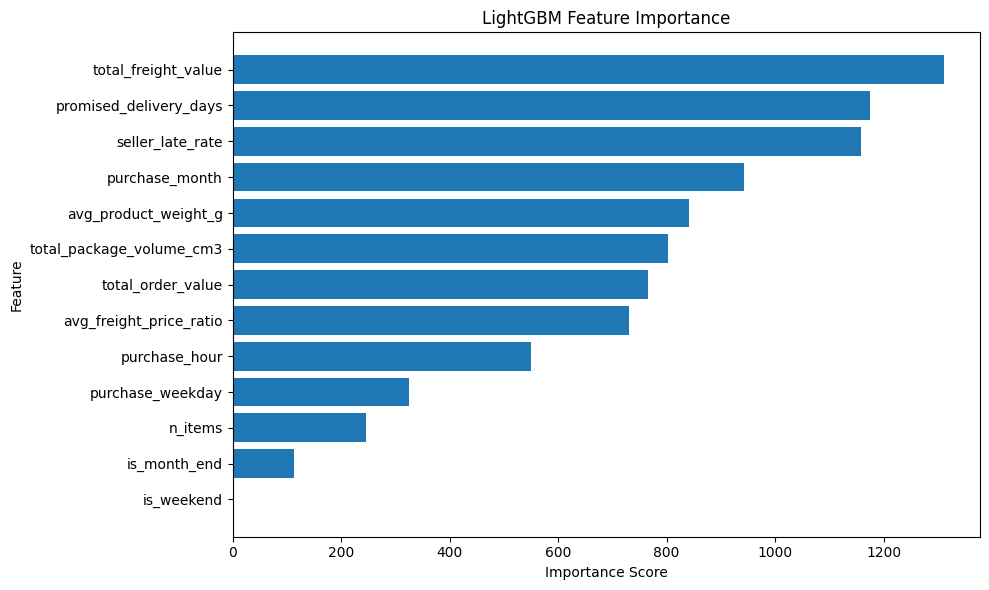

In [ ]:
# looking at which features matter most to the LightGBM model

import pandas as pd
import matplotlib.pyplot as plt

# extracting feature importance scores
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgbm.feature_importances_
})

# sorting highest -> lowest
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("feature importance ranking:")
print(importance_df)

# plotting
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# model explainability with SHAP
# this helps explain WHY the model predicts an order will be late

import shap

In [ ]:
# creating a SHAP explainer for the trained LightGBM model

explainer = shap.TreeExplainer(lgbm)

In [ ]:
sample_X = X_test.sample(1000, random_state=42)

In [ ]:
shap_values = explainer.shap_values(sample_X)

print("SHAP values calculated successfully")

SHAP values calculated successfully


e:\Portfolio\churn-radar\venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


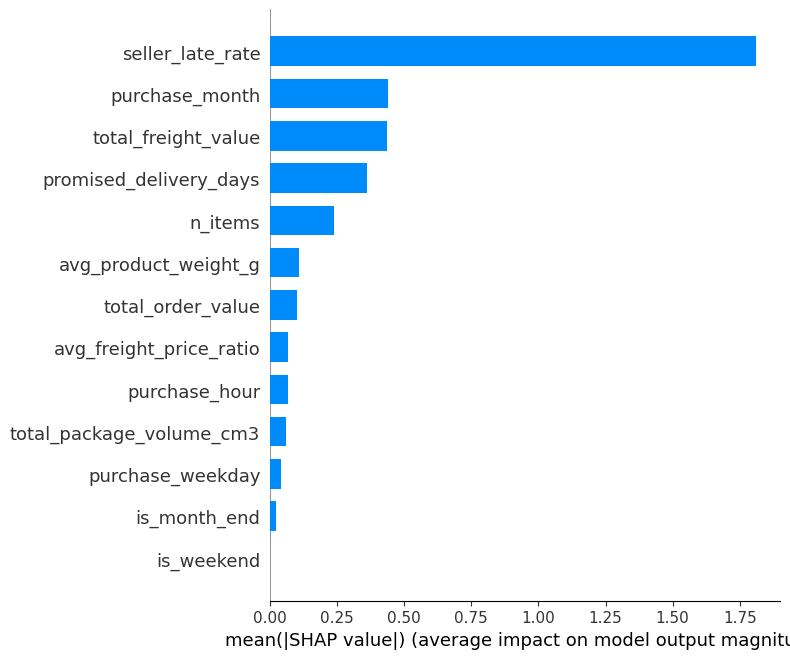

In [ ]:
if isinstance(shap_values, list):
    shap_values_late = shap_values[1]
else:
    shap_values_late = shap_values

shap.summary_plot(
    shap_values_late,
    sample_X,
    plot_type="bar"
)